In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression as lr 
from sklearn.linear_model import Lasso
import matplotlib.pyplot as plt
import statsmodels.api as sm
from itertools import combinations

## Data:

In [2]:
# Load Data:
# sørg for at bruge sti til hvor du har placeret data
path_train = r"C:\Users\oskar\OneDrive\Desktop\4 Semester\Dataproject\Federated-dental-risk-vol2\federated-dental-risk-prediction\data\raw\synthetic_dataset_A_non-iid.csv"
df = pd.read_csv(path_train)

path_test = r"C:\Users\oskar\OneDrive\Desktop\4 Semester\Dataproject\Federated-dental-risk-vol2\federated-dental-risk-prediction\data\processed\A\global_test_set_non-iid.csv"
test_data = pd.read_csv(path_test)

# Define variabels:
variables = df.columns[2:27].tolist()

X_train = df[variables].copy()
X_test = test_data[variables].copy()

# Function for interaktions:
def add_interactions(X, variables):
    interaction_cols = {}

    for v1, v2 in combinations(variables, 2):
        interaction_cols[f"{v1}_x_{v2}"] = X[v1] * X[v2]

    interaction_df = pd.DataFrame(interaction_cols, index=X.index)

    return pd.concat([X, interaction_df], axis=1)

#Add interactions
train_design_df = add_interactions(X_train, variables)
test_design_df = add_interactions(X_test, variables)

# Sørg for samme kolonner (meget vigtigt!)
test_design_df = test_design_df[train_design_df.columns]


# Standardise
scaler = StandardScaler()

train_design = pd.DataFrame(
    scaler.fit_transform(train_design_df),
    columns=train_design_df.columns,
    index=train_design_df.index
)

test_design = pd.DataFrame(
    scaler.transform(test_design_df),
    columns=test_design_df.columns,
    index=test_design_df.index
)

## Functions:

In [3]:
def predict_and_group_centralized(test_df, variables, models):
    """
    Laver predictions og tertil-grupper for hver complication på test_df.
    
    Tilføjer for hver complication:
      - Risk_XXX_group
    
    Returnerer:
      out_df, cutoffs
    """
    out = test_df.copy()
    cutoffs = {}

    n = len(test_df)
    d = len(variables)

    X_test = np.zeros((n, d))
    for i in range(d):
        X_test[:, i] = test_df[variables[i]]

    for complication, params in models.items():
        intercept = params["intercept"]
        coefs = params["coef"]

        y_hat = intercept + X_test @ coefs

        q1 = np.quantile(y_hat, 1/3)
        q2 = np.quantile(y_hat, 2/3)

        groups = np.where(
            y_hat <= q1, 0,
            np.where(y_hat <= q2, 1, 2)
        )

        out[f"{complication}_group"] = groups

        cutoffs[complication] = {
            "q1": q1,
            "q2": q2
        }

    return out, cutoffs


def soft_threshold(x, lam):
    """
    Prox-operator for L1 penalty.
    """
    return np.sign(x) * np.maximum(np.abs(x) - lam, 0.0)


def client_update_lasso(
    client_df,
    complication,
    variables,
    beta,
    lr=0.01,
    local_steps=5,
):
    """
    One client update for federated LASSO.

    Parameters:
    client_df : pd.DataFrame
        Data for a single client.
    complication : str
        Target column.
    variables : list[str]
        Feature columns. Assumed already standardized.
    beta : np.ndarray
        Current global parameter vector of length d+1:
        beta[0] = intercept, beta[1:] = coefficients
    lr : float, default = 0.01
        Learning rate.
    local_steps : int, default = 5
        Number of local gradient steps.

    Returns:
    beta_local : np.ndarray
        Updated local parameter vector.
    n_local : int
        Number of observations on this client.
    """
    n_local = len(client_df)
    d = len(variables)

    if n_local == 0:
        return beta.copy(), 0

    X = client_df[variables].to_numpy(dtype=float)
    y = client_df[complication].to_numpy(dtype=float)

    # Design matrix with intercept
    X_design = np.column_stack([np.ones(n_local), X])

    beta_local = beta.copy()

    for _ in range(local_steps):
        residual = X_design @ beta_local - y
        grad = (X_design.T @ residual) / n_local
        beta_local -= lr * grad

    return beta_local, n_local


def federated_lasso_single(
    df,
    variables,
    complication,
    num_clients,
    rounds=100,
    lr=0.01,
    lam=0.01,
    local_steps=5,
    weighted=True,
):
    """
    Federated lasso for one target column.

    assumes:
    - df has a column called 'Client'
    - features in `variables` are already standardized
    - client ids are 1, 2, ..., num_clients

    returns:
    intercept : float
    coefs : np.ndarray
    """
    d = len(variables)

    # beta[0] = intercept, beta[1:] = coefficients
    beta = np.zeros(d + 1, dtype=float)

    for _ in range(rounds):
        local_betas = []
        local_sizes = []

        for client_id in range(1, num_clients + 1):
            client_df = df[df["Client"] == client_id]

            beta_local, n_local = client_update_lasso(
                client_df=client_df,
                complication=complication,
                variables=variables,
                beta=beta,
                lr=lr,
                local_steps=local_steps,
            )

            if n_local > 0:
                local_betas.append(beta_local)
                local_sizes.append(n_local)

        if len(local_betas) == 0:
            break

        local_betas = np.array(local_betas)
        local_sizes = np.array(local_sizes, dtype=float)

        # Aggregate local models
        if weighted:
            beta = np.average(local_betas, axis=0, weights=local_sizes)
        else:
            beta = np.mean(local_betas, axis=0)

        # Prox step: apply lr*lam only to non-intercept coefficients
        beta[1:] = soft_threshold(beta[1:], lr * lam)

    intercept = beta[0]
    coefs = beta[1:]
    return intercept, coefs


def macro_f1_3class(y_true, y_pred):
    f1s = []

    for cls in [0, 1, 2]:
        tp = np.sum((y_true == cls) & (y_pred == cls))
        fp = np.sum((y_true != cls) & (y_pred == cls))
        fn = np.sum((y_true == cls) & (y_pred != cls))

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0

        f1 = (
            2 * precision * recall / (precision + recall)
            if (precision + recall) > 0 else 0.0
        )

        f1s.append(f1)

    return np.mean(f1s)


def tune_federated_lasso_lambda(
    train_df,
    val_df,
    variables,
    complications,
    lambdas,
    num_clients=10,
    rounds=100,
    lr=0.01,
    local_steps=5,
    weighted=True,
):
    '''
    federated udgave af funktionen, der finder en optimal værdi af lambda. 
    '''
    results = []

    for lam in lambdas:
        models = {}

        for complication in complications:
            intercept, coefs = federated_lasso_single(
                df=train_df,
                variables=variables,
                complication=complication,
                num_clients=num_clients,
                rounds=rounds,
                lr=lr,
                lam=lam,
                local_steps=local_steps,
                weighted=weighted,
            )

            models[complication] = {
                "intercept": intercept,
                "coef": coefs
            }

        # predict på validation set
        val_with_preds, _ = predict_and_group_centralized(
            test_df=val_df,
            variables=variables,
            models=models
        )

        macro_f1s = []

        for complication in complications:
            true_col = complication.replace("Risk_", "Risk_Category_", 1)
            pred_col = f"{complication}_group"

            y_true = val_with_preds[true_col].to_numpy().ravel()
            y_pred = val_with_preds[pred_col].to_numpy().ravel()

            macro_f1s.append(macro_f1_3class(y_true, y_pred))

        overall_f1 = np.mean(macro_f1s)

        results.append((lam, overall_f1))

        print(f"lambda={lam:.5f} -> F1={overall_f1:.4f}")

    return results

def name_of_features(coefs, variabels):
    idx = []
    for i in range(len(coefs)):
        if coefs[i] > 0:
            idx.append(i)
    
    return [variabels[i] for i in idx]

def metrics_for_one_complication(y_true, y_pred):
    """
    complication fx 'Risk_AlveolarOsteitis'
    
    Bruger:
      true: Risk_Category_AlveolarOsteitis
      pred: Risk_AlveolarOsteitis_group
    """
    
    results = {}
    
    for cls in [0, 1, 2]:
        tp = np.sum((y_true == cls) & (y_pred == cls))
        fp = np.sum((y_true != cls) & (y_pred == cls))
        fn = np.sum((y_true == cls) & (y_pred != cls))
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
        
        results[cls] = {
            "TP": tp,
            "FP": fp,
            "FN": fn,
            "precision": precision,
            "recall": recall,
            "f1": f1
        }
    
    macro_f1 = np.mean([results[cls]["f1"] for cls in [0, 1, 2]])
    
    return {
        "per_class": results,
        "macro_f1": macro_f1
    }

def predict_from_coefs(df, variables, intercept, coefs):
    """
    Beregner y-hat = intercept + X beta
    for alle rækker i df.
    """
    X = df[variables].to_numpy()
    y_hat = intercept + X @ coefs
    return y_hat

def assign_tertiles(y_hat):
    """
    Deler y_hat i 3 grupper baseret på 1/3 og 2/3 kvantiler.
    Returnerer både gruppe-labels og grænserne.
    """
    q1 = np.quantile(y_hat, 1/3)
    q2 = np.quantile(y_hat, 2/3)

    groups = np.where(
        y_hat <= q1, 0,
        np.where(y_hat <= q2, 1, 2)
    )

    return groups, q1, q2

## Results:

In [18]:
base_variables = [
    col for col in train_design.columns
    if col not in [
        "Client",
        "Risk_AlveolarOsteitis",
        "Risk_Category_AlveolarOsteitis"
    ]
]

train_design["Risk_AlveolarOsteitis"] = df["Risk_AlveolarOsteitis"]
train_design["Client"] = df["Client"]
train_design["Risk_Category_AlveolarOsteitis"] = df["Risk_Category_AlveolarOsteitis"]
test_design["Risk_AlveolarOsteitis"] = test_data["Risk_AlveolarOsteitis"]
test_design["Risk_Category_AlveolarOsteitis"] = test_data["Risk_Category_AlveolarOsteitis"]

intercept, coefs = federated_lasso_single(
    train_design,
    base_variables,
    "Risk_AlveolarOsteitis",
    num_clients = 10,
    rounds=100,
    lr=0.01,
    lam=0.012689610031679234,
    local_steps=5,
    weighted=True,
)

fl_lasso_names = name_of_features(coefs, base_variables)
len(fl_lasso_names)


21

In [19]:
base_variables = [
    col for col in train_design.columns
    if col not in ["Patient", "Client", "Risk_AlveolarOsteitis", "Risk_Category_AlveolarOsteitis"]
]

preds = predict_from_coefs(test_design, base_variables, intercept, coefs)
cat_pred, a, b = assign_tertiles(preds)

y_true = test_data["Risk_Category_AlveolarOsteitis"].values
y_pred = cat_pred

metrics_for_one_complication(y_true, y_pred)

{'per_class': {0: {'TP': np.int64(788),
   'FP': np.int64(212),
   'FN': np.int64(177),
   'precision': np.float64(0.788),
   'recall': np.float64(0.816580310880829),
   'f1': np.float64(0.8020356234096693)},
  1: {'TP': np.int64(553),
   'FP': np.int64(447),
   'FN': np.int64(474),
   'precision': np.float64(0.553),
   'recall': np.float64(0.5384615384615384),
   'f1': np.float64(0.5456339417858905)},
  2: {'TP': np.int64(707),
   'FP': np.int64(293),
   'FN': np.int64(301),
   'precision': np.float64(0.707),
   'recall': np.float64(0.7013888888888888),
   'f1': np.float64(0.704183266932271)}},
 'macro_f1': np.float64(0.6839509440426103)}

In [6]:

lambdas = np.logspace(-5, 0, 30)

results_fed = tune_federated_lasso_lambda(
    train_df=train_design,
    val_df=test_design,  # helst validation, ikke final test
    variables=base_variables,
    complications=["Risk_AlveolarOsteitis"],
    lambdas=lambdas,
    num_clients=10,
    rounds=100,
    lr=0.01,
    local_steps=5,
    weighted=True
)

lambda=0.00001 -> F1=0.6516
lambda=0.00001 -> F1=0.6516
lambda=0.00002 -> F1=0.6516
lambda=0.00003 -> F1=0.6516
lambda=0.00005 -> F1=0.6522
lambda=0.00007 -> F1=0.6509
lambda=0.00011 -> F1=0.6523
lambda=0.00016 -> F1=0.6536
lambda=0.00024 -> F1=0.6542
lambda=0.00036 -> F1=0.6546
lambda=0.00053 -> F1=0.6559
lambda=0.00079 -> F1=0.6572
lambda=0.00117 -> F1=0.6609
lambda=0.00174 -> F1=0.6632
lambda=0.00259 -> F1=0.6699
lambda=0.00386 -> F1=0.6742
lambda=0.00574 -> F1=0.6829
lambda=0.00853 -> F1=0.6836
lambda=0.01269 -> F1=0.6840
lambda=0.01887 -> F1=0.6831
lambda=0.02807 -> F1=0.6822
lambda=0.04175 -> F1=0.6761
lambda=0.06210 -> F1=0.6611
lambda=0.09237 -> F1=0.6446
lambda=0.13738 -> F1=0.5944
lambda=0.20434 -> F1=0.1623
lambda=0.30392 -> F1=0.1623
lambda=0.45204 -> F1=0.1623
lambda=0.67234 -> F1=0.1623
lambda=1.00000 -> F1=0.1623


<>:11: SyntaxWarning: invalid escape sequence '\l'
<>:12: SyntaxWarning: invalid escape sequence '\l'
<>:11: SyntaxWarning: invalid escape sequence '\l'
<>:12: SyntaxWarning: invalid escape sequence '\l'
C:\Users\oskar\AppData\Local\Temp\ipykernel_10868\755542286.py:11: SyntaxWarning: invalid escape sequence '\l'
  plt.title("F1 score across $\lambda$'s in LASSO")
C:\Users\oskar\AppData\Local\Temp\ipykernel_10868\755542286.py:12: SyntaxWarning: invalid escape sequence '\l'
  ax.axvline(x=max_lambda, linestyle=':', color='black', label = "Optimal $\lambda$")


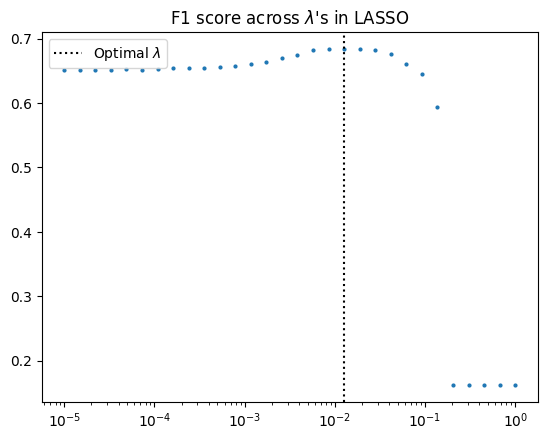

In [9]:
#plotter resultater
results = np.array(results_fed).T

idx = np.argmax(results[1])
max_F1 = max(results[1])
max_lambda = results[0, idx]

fig, ax = plt.subplots()
ax.plot(results[0], results[1], "o", markersize = 2)
plt.xscale('log')
plt.title("F1 score across $\lambda$'s in LASSO")
ax.axvline(x=max_lambda, linestyle=':', color='black', label = "Optimal $\lambda$")
plt.legend()

In [21]:
max_lambda

np.float64(0.012689610031679234)